In [1]:
from heaict.cats.surface import get_activity_selectivity
import matplotlib.pyplot as plt
import numpy as np
import pickle

get site adsorption energies data

In [2]:
with open(f'Data/Site_adsenergy/Ni0.05-Pd0.34-Cu0.14-Mo0.35-Ru0.12.pkl', 'rb') as file:
    site_adsenergy = pickle.load(file)

# Figure 3b

In [3]:
for ads in site_adsenergy.keys():
    print(ads, min(site_adsenergy[ads]), max(site_adsenergy[ads]))

H -0.8903993964195251 0.024629607796669006
N2 -1.395434021949768 0.4408607482910156
NH -2.3132715225219727 0.3508411645889282
NH3 -1.6631075143814087 -0.8562084436416626
NNH -1.3460122346878052 1.6174664497375488


In [4]:
bins=np.arange(-2.4, 1.7, 0.05)

counts = []
for ads in ['N2', 'NNH', 'NH', 'NH3', 'H']:
    indices=list(np.digitize(site_adsenergy[ads],bins))
    count = []
    for b in range(len(bins)):
        count.append(indices.count(b))
    counts.append(count)
counts=np.array(counts)

Text(-2.3, 1460, 'Ni$_5$Pd$_{34}$Cu$_{14}$Mo$_{35}$Ru$_{12}$')

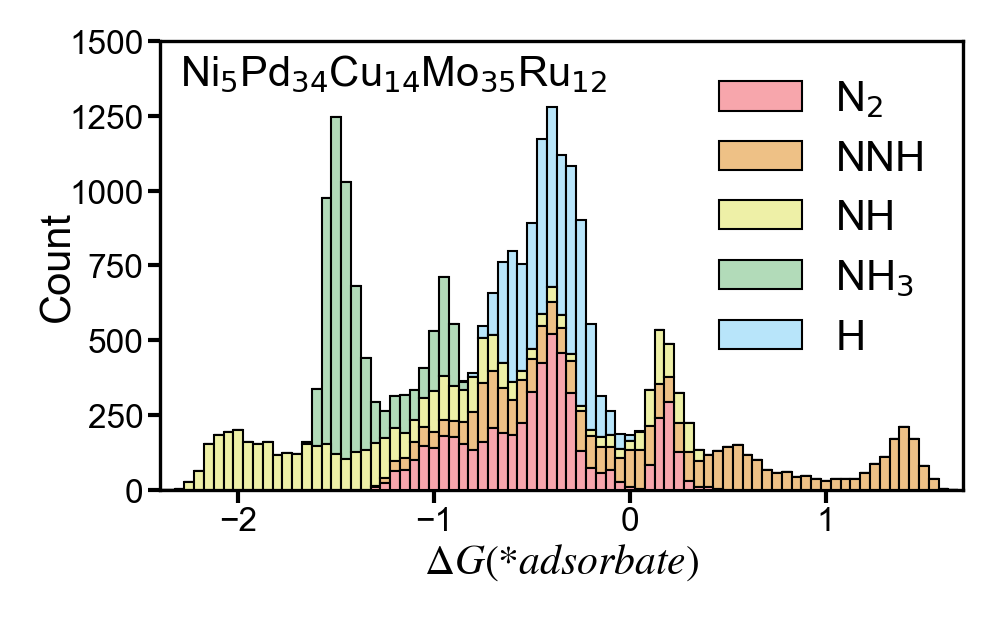

In [8]:
plt.rc('font',family='Arial')
fig=plt.figure(figsize=(8/2.54, (3.7+1.2)/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

ax1=fig.add_axes([1.1/8, (1.0)/(3.7+1.2), 6.8/8, 3.8/(3.7+1.2)])
ax1.set_zorder(2)
ax1.patch.set_alpha(0.0)
ax1.tick_params(length=3,width=1,labelsize=8,pad=1)

ax1.bar(bins, counts[0], label='N$_2$', width=(1.7+2.4)/len(bins), alpha=1, zorder=6, color='#F7A6AC',ec='k', lw=0.5)
ax1.bar(bins, counts[1], label='NNH',   width=(1.7+2.4)/len(bins), alpha=1, zorder=5, color='#EEC186',ec='k', lw=0.5, bottom=counts[0])
ax1.bar(bins, counts[2], label='NH',    width=(1.7+2.4)/len(bins), alpha=1, zorder=4, color='#EEF0A7',ec='k', lw=0.5, bottom=np.sum(counts[:2],axis=0))
ax1.bar(bins, counts[3], label='NH$_3$',width=(1.7+2.4)/len(bins), alpha=1, zorder=3, color='#B2DBB9',ec='k', lw=0.5, bottom=np.sum(counts[:3],axis=0))
ax1.bar(bins, counts[4], label='H',     width=(1.7+2.4)/len(bins), alpha=1, zorder=2, color='#B8E5FA',ec='k', lw=0.5, bottom=np.sum(counts[:4],axis=0))

ax1.set_xlabel('$\Delta G(*adsorbate)$', fontsize=10, labelpad=1, math_fontfamily='stix')
ax1.set_ylabel('Count', fontsize=10, labelpad=-2)
ax1.set_xlim(-2.4, 1.7)
ax1.set_ylim(0, 1500)
ax1.legend(fontsize=10, edgecolor='none',facecolor='none')
ax1.text(-2.3,1460, 'Ni$_5$Pd$_{34}$Cu$_{14}$Mo$_{35}$Ru$_{12}$', fontsize=10, va='top')

# fig.savefig('Figure_3_b.tif',dpi=300)

# Figure 3c

In [3]:
Tmax = 0.8275555555555556
U_V_NRR, U_T_NRR, U_PDS_G1, U_PDS_G2, U_PDS_NRR, U_V_HER, U_T_HER, U_PDS_G3, U_PDS_G4, U_PDS_HER, U_FE = get_activity_selectivity(site_adsenergy, return_all=True)
V_max_NRR, V_max_HER, FE, U_opt = get_activity_selectivity(site_adsenergy)
print(V_max_NRR, V_max_HER, FE, U_opt)

0.10513782486517012 0.3376788841927919 0.4829538584415602 -0.32000000000000006


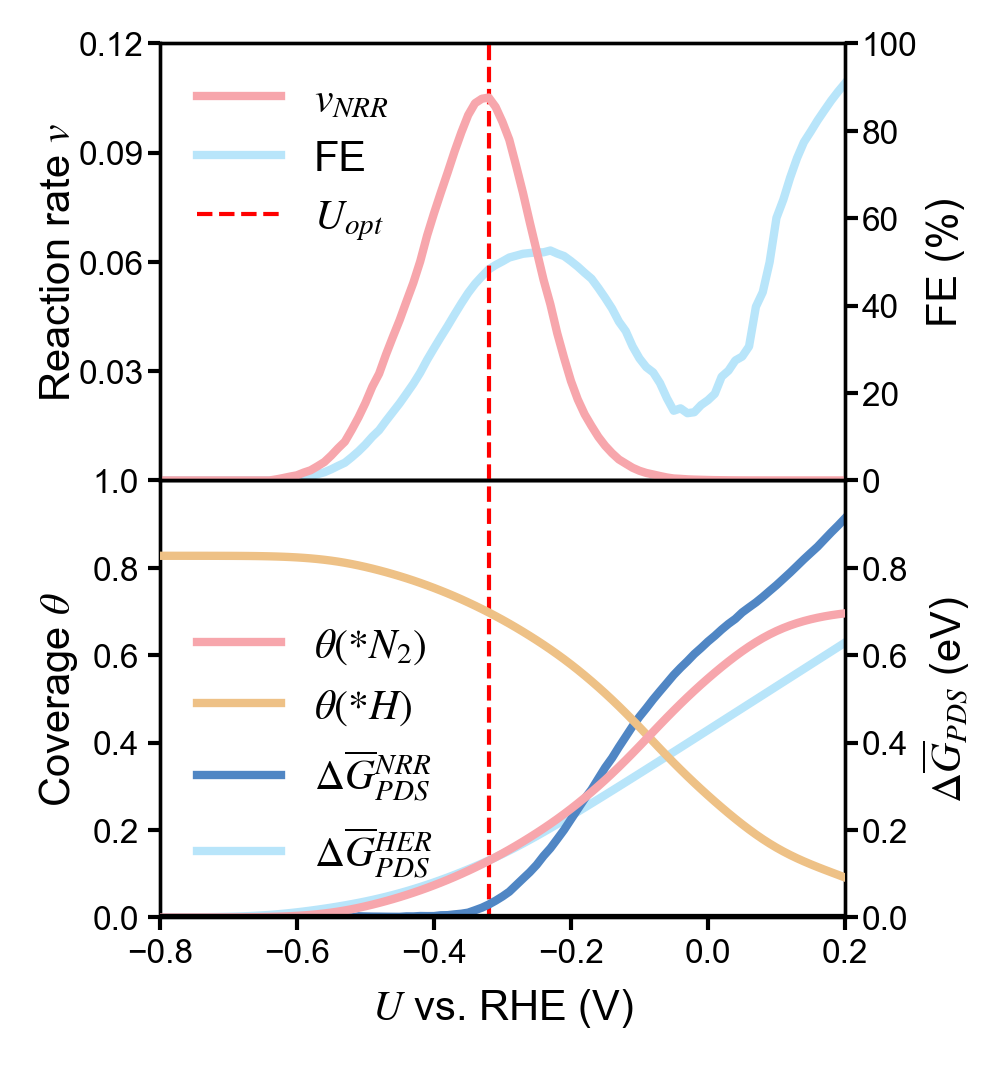

In [17]:
plt.rc('font',family='Arial')
plt.rcParams['mathtext.fontset'] = 'stix'

l=8;h=3.7*2+1.2
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

Uspace = np.linspace(-0.8, 0.2, 101)
ylim_vNRR=(0, 0.12)
ytic_vNRR=[0.03, 0.06, 0.09, 0.12]
Tmax = 0.82755
ylim_U=(0, 1)
ytic_U=[0, 0.2, 0.4, 0.6, 0.8]
# ax1-U_V_NRR
ax1=fig.add_axes([1.1/l, (1.08+3.7)/h, 5.8/l, 3.7/h])
ax1.set_zorder(2); ax1.patch.set_alpha(0.0)
ax1.tick_params(length=3,width=1,labelsize=8,pad=1)

ax1.plot(Uspace, U_V_NRR, lw=2, label='$v_{NRR}$', color='#F7A6AC',zorder=2)
ax1.plot([-1,-1],[1, 2], lw=2, label='FE', color='#B8E5FA')
ax1.plot([U_opt, U_opt], [-1, 1], 'r--', lw=1, zorder=0, label='$U_{opt}$')
ax1.set_xticks([]);ax1.set_xlim(-0.8, 0.2)
ax1.set_ylim(*ylim_vNRR);ax1.set_yticks(ytic_vNRR)
ax1.set_ylabel('Reaction rate $v$', fontsize=10, labelpad=0, math_fontfamily='stix')
ax1.legend(fontsize=10, edgecolor='none',facecolor='none', loc=2)

# ax11 - FE
ax11 = ax1.twinx();ax11.set_zorder(1)
ax11.tick_params(length=3,width=1,labelsize=8,pad=1)

ax11.plot(Uspace, np.array(U_FE)*100, lw=2, color='#B8E5FA', zorder=1)
ax11.set_ylabel('FE (%)', labelpad=2, fontsize=10)
ax11.set_ylim(0, 100); ax11.set_yticks([0, 20, 40, 60, 80, 100])

# ax2 - T
ax2=fig.add_axes([1.1/l, 1.08/h, 5.8/l, 3.7/h])
ax2.set_zorder(2)
ax2.patch.set_alpha(0.0)
ax2.tick_params(length=3,width=1,labelsize=8,pad=2)

ax2.plot(Uspace, np.array(U_T_NRR)*Tmax, lw=2, label='$\\theta (*N_2)$', color='#F7A6AC', zorder=4)
ax2.plot(Uspace, np.array(U_T_HER)*Tmax, lw=2, label='$\\theta (*H)$', color='#EEC186', zorder=3)
ax2.plot([-1,1], [0,0],c='k',zorder=10)
ax2.plot([-1,-1],[2,3],lw=2,label='$\Delta \overline{G}_{PDS}^{NRR}$', color='#5086C4')
ax2.plot([-1,-1],[2,3],lw=2,label='$\Delta \overline{G}_{PDS}^{HER}$', color='#B8E5FA')

ax2.set_xlabel('$U$ vs. RHE (V)', fontsize=10)
ax2.set_ylabel('Coverage $\\theta$', fontsize=10, labelpad=3)
ax2.set_xlim(-0.8, 0.2)
ax2.set_ylim(0, 1.0); ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax2.legend(fontsize=10,edgecolor='none',facecolor='none')
# ax22 - PDS
ax22 = ax2.twinx()
ax22.set_zorder(1)
ax22.tick_params(length=3,width=1,labelsize=8,pad=1)
Uidx_start = max(np.where(np.array(U_PDS_NRR) == -1)[0])
ax22.plot(Uspace[Uidx_start+1:], U_PDS_NRR[Uidx_start+1:], lw=2, label='NRR', color='#5086C4', zorder=2)
ax22.plot(Uspace, U_PDS_HER, lw=2, label='HER', color='#B8E5FA', zorder=1)
ax22.plot([U_opt, U_opt], [-1, 1], 'r--', lw=1, zorder=0)
ax22.set_ylabel('$\Delta \overline{G}_{PDS}$ (eV)', labelpad=3, fontsize=10)
ax22.set_ylim(*ylim_U);ax22.set_yticks(ytic_U)

# fig.savefig('Figure_3_c.tif',dpi=300)